# Hypothesis 1, Part 1: Running Unsupervised Model with MSE and NCC with No Affine Preprocessing

- In order to determine if label-driven approaches are required, we must experiment with models with loss functions driven by regularisation and similarity metrics
- Here, we run models using MSE and NCC using the literature recommended hyperparameters to demonstrate how useless they are by themselves. No affine prepocessing is used at first.

## Imports

In [7]:
# --- Standard library ---
import os   # Filesystem and environment access
import sys  # Interpreter/runtime access
import re   # Regular expressions for string parsing
import csv  # Reading/writing CSV files (e.g. logging experiment results)

# --- Scientific computing ---
import numpy as np  # Numerical arrays and operations
from skimage.transform import resize  # Resizing/rescaling images
from scipy.ndimage import _ni_support  # Internal SciPy helper used by surface-distance computations
from scipy.ndimage import generate_binary_structure, distance_transform_edt, binary_erosion  # Binary morphology and distance transforms (evaluation metrics)

# --- Deep learning (TensorFlow / Keras) ---
import tensorflow as tf  # Deep learning framework
assert tf.__version__.startswith('2.'), 'This tutorial assumes Tensorflow 2.0+'
from tensorflow import keras  # High-level Keras API
from keras import layers  # Neural network layer definitions

# --- Learning-based image registration ---
import voxelmorph as vxm  # VoxelMorph deformable registration framework
import neurite as ne  # Neurite deep-learning utilities (used by VoxelMorph)

# --- Medical image I/O ---
import nibabel as nib  # Reading/writing NIfTI neuroimaging volumes
import SimpleITK as sitk  # Medical image processing toolkit (filters, registration, I/O)

# --- Visualisation ---
import matplotlib.pyplot as plt  # Plotting images and training curves

# --- Utilities ---
from tqdm import tqdm  # Progress bars

# For GPU
# #os.environ["CUDA_VISIBLE_DEVICES"]=""

## Pipeline, broken into modules

Each stage lives in its own cell and ends
with a small **self-check** that produces an insightful output *without* needing the dataset (synthetic stand-ins
are used where data would normally be required), so the wiring can be inspected before the data arrives.

| # | Module | Purpose |
|---|--------|---------|
| 1 | Configuration | Working voxel-grid shapes shared by every stage |
| 2 | Backbone | Residual U-Net regressing the dense displacement field (DDF) |
| 3 | Caching | Load + resize + normalise the NIfTI volumes into memory |
| 4 | Generators | Infinite shuffled train batches / deterministic validation batches |
| 5 | Registration network | Backbone + spatial transformer warping the moving image |
| 6 | Losses | The 2x2 grid: similarity (NCC/MSE) x weak supervision |
| 7 | Validation | Warped-label Dice scoring + qualitative slice / flow-field figures |
| 8 | Trainer | Per-trial fit / validate / checkpoint loop |
| 9 | Orchestrator | `run_experiments`, the entry point used by the sweep cells below |


In [18]:
# =========================================
# 1. CONFIGURATION - SHAPES WE ARE WORKING WITH
# =========================================

moving_image_shape = (64, 64, 64, 1)  # ultrasound volumes, channel-last
fixed_image_shape = (64, 64, 64, 1)   # MR volumes, channel-last

print(f"moving (US) volume shape : {moving_image_shape}")
print(f"fixed  (MR) volume shape : {fixed_image_shape}")
print(f"the network predicts one 3-vector of displacements per fixed voxel -> a DDF of shape {fixed_image_shape[:-1] + (3,)}")


moving (US) volume shape : (64, 64, 64, 1)
fixed  (MR) volume shape : (64, 64, 64, 1)
the network predicts one 3-vector of displacements per fixed voxel -> a DDF of shape (64, 64, 64, 3)


### 2. Backbone model architecture

A residual U-Net taking the concatenated moving/fixed pair and regressing a **dense displacement field (DDF)**:
one 3-vector of displacements per voxel of the fixed grid.

Information on Keras at: 
```
https://keras.io/guides/functional_api/
```
Vido On U-Net Architecture:
```
https://www.youtube.com/watch?v=NhdzGfB1q74
```

In [19]:
# ==========================================
# 2. BACKBONE - U-NET REGRESSING THE DDF
# ==========================================

def get_model(moving_image_shape, fixed_image_shape, with_label_inputs=True,
              up_filters=[64, 128, 256], down_filters=[256, 128, 64, 32]):
    """Residual U-Net: concatenated moving/fixed pair in, dense displacement field (DDF) out."""

    input_moving_image = keras.Input(moving_image_shape)
    input_fixed_image = keras.Input(fixed_image_shape)

    if with_label_inputs:
        input_moving_label = keras.Input(moving_image_shape)
        input_fixed_label = keras.Input(fixed_image_shape)

    concatenate_layer = layers.Concatenate(axis=-1)([input_moving_image, input_fixed_image])

    ### [First half of the network: downsampling inputs] ###

    # Entry block
    x = layers.Conv3D(32, 3, strides=2, padding="same")(concatenate_layer)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    # Blocks 1, 2, 3 are identical apart from the feature depth.
    for filters in up_filters:
        x = layers.Activation("relu")(x)
        x = layers.Conv3D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.Conv3D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling3D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv3D(filters, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    ### [Second half of the network: upsampling inputs] ###

    for filters in down_filters:
        x = layers.Activation("relu")(x)
        x = layers.Conv3DTranspose(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.Conv3DTranspose(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.UpSampling3D(2)(x)

        # Project residual
        residual = layers.UpSampling3D(2)(previous_block_activation)
        residual = layers.Conv3D(filters, 1, padding="same")(residual)
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    # Add a per-pixel displacement prediction layer
    out_ddf = layers.Conv3D(3, 3, activation="linear", padding="same")(x)

    # Define the model
    if with_label_inputs:
        model = keras.Model(inputs=[input_moving_image, input_fixed_image, input_moving_label, input_fixed_label], outputs=[out_ddf])
    else:
        model = keras.Model(inputs=[input_moving_image, input_fixed_image], outputs=[out_ddf])
    return model


# --- Self-check: build the unsupervised backbone and trace the tensors through it ---

backbone = get_model(moving_image_shape, fixed_image_shape, with_label_inputs=False)

print("Backbone inputs:")
for tensor in backbone.inputs:
    print(f"    {tensor.name:22s} {tensor.shape}")

print("\nBackbone output:")
for tensor in backbone.outputs:
    print(f"    {tensor.name:22s} {tensor.shape}")

print(f"\nTrainable parameters: {backbone.count_params():,}")


Backbone inputs:
    keras_tensor_232       (None, 64, 64, 64, 1)
    keras_tensor_233       (None, 64, 64, 64, 1)

Backbone output:
    keras_tensor_305       (None, 64, 64, 64, 3)

Trainable parameters: 8,930,659


### 3. Caching the dataset

Images are resized onto the working grid and min-max normalised; labels stay at native resolution and are resized
on-the-fly inside the generators (a fresh random structure is drawn per training batch).


In [20]:
# ==========================================
# 3. CACHE RELEVANT DATA
# ==========================================

def resize_3d_image(image, shape):
    """Resize onto the working grid, then min-max normalise intensities to [0, 1]."""
    resized_image = resize(image, output_shape=shape)
    if np.amax(resized_image) == np.amin(resized_image):
        normalised_image = resized_image
    else:
        normalised_image = (resized_image-np.amin(resized_image))/(np.amax(resized_image)-np.amin(resized_image))
    return normalised_image


def load_dataset_into_cache(f_path, moving_image_shape, fixed_image_shape, with_label_inputs=True):
    """Load every us/mr image (+label) volume below f_path into memory.
    Returns {file_name: {'moving': ..., 'fixed': ...[, 'moving_label': ..., 'fixed_label': ...]}}."""
    moving_images_path = os.path.join(f_path, 'us_images')
    fixed_images_path = os.path.join(f_path, 'mr_images')

    all_names = np.array(os.listdir(fixed_images_path))

    cache = {}

    for f_name in all_names:
        moving_image = nib.load(os.path.join(moving_images_path, f_name)).get_fdata()
        fixed_image = nib.load(os.path.join(fixed_images_path, f_name)).get_fdata()

        moving_image_resized = resize_3d_image(moving_image, moving_image_shape)
        fixed_image_resized = resize_3d_image(fixed_image, fixed_image_shape)

        entry = {
            "moving": moving_image_resized,
            "fixed": fixed_image_resized,
        }

        if with_label_inputs:
            moving_labels_path = os.path.join(f_path, 'us_labels')
            fixed_labels_path = os.path.join(f_path, 'mr_labels')

            moving_label = nib.load(os.path.join(moving_labels_path, f_name)).get_fdata()
            fixed_label = nib.load(os.path.join(fixed_labels_path, f_name)).get_fdata()

            entry["moving_label"] = moving_label
            entry["fixed_label"] = fixed_label

        cache[f_name] = entry

    return cache


# --- Self-check: exercise the resize/normalise path on a synthetic volume ---

native_volume = np.random.rand(176, 256, 256)  # pretend this came off the scanner at native resolution
working_volume = resize_3d_image(native_volume, moving_image_shape[:-1])

print(f"resized {native_volume.shape} -> {working_volume.shape}")
print(f"intensity range after min-max normalisation: [{working_volume.min():.3f}, {working_volume.max():.3f}]")

# Once nifti_data/{train,val} exists on disk, load_dataset_into_cache returns e.g.:
# {
#     '<case>.nii.gz': {
#         'moving':       float array, moving_image_shape  (resized + normalised),
#         'fixed':        float array, fixed_image_shape   (resized + normalised),
#         'moving_label': native-resolution label volume (..., ..., ..., 6),
#         'fixed_label':  native-resolution label volume (..., ..., ..., 6),
#     }, ...
# }


resized (176, 256, 256) -> (64, 64, 64)
intensity range after min-max normalisation: [0.000, 1.000]


### 4. Generators

`train_generator_` yields shuffled batches forever (Keras' `fit` pulls `steps_per_epoch` of them per trial);
`test_generator` walks the cache deterministically so validation covers every case exactly once.
The targets pack three heads for Keras: the fixed image (similarity loss), a zero field (regularisation loss)
and the fixed label (Dice loss).


In [21]:
# ==========================================
# 4. TRAIN AND TEST GENERATORS
# ==========================================

def train_generator_(cache, batch_size, moving_image_shape, fixed_image_shape, with_label_inputs=True):
    """Infinite shuffled batches. y_true = [fixed image, zero DDF (regularisation target), fixed label]."""

    all_names = list(cache.keys())

    while True:
        batch_names = np.random.permutation(all_names)[:batch_size]

        moving_images_batch = np.zeros((batch_size, *moving_image_shape))
        fixed_images_batch = np.zeros((batch_size, *fixed_image_shape))

        if with_label_inputs:
            moving_labels_batch = np.zeros((batch_size, *moving_image_shape))
            fixed_labels_batch = np.zeros((batch_size, *fixed_image_shape))

        for i, f_name in enumerate(batch_names):
            entry = cache[f_name]
            moving = entry["moving"]
            fixed  = entry["fixed"]

            if with_label_inputs:
                label_to_select = np.random.randint(6)
                moving_label = resize_3d_image(entry["moving_label"][:, :, :, label_to_select], moving_image_shape)
                fixed_label  = resize_3d_image(entry["fixed_label"][:, :, :, label_to_select], fixed_image_shape)
            else:
                moving_label, fixed_label = None, None

            # assign into batch
            moving_images_batch[i] = moving
            fixed_images_batch[i]  = fixed
            if with_label_inputs:
                moving_labels_batch[i] = moving_label
                fixed_labels_batch[i]  = fixed_label

        zero_phis = np.zeros([batch_size, *moving_image_shape[:-1], 3])

        if with_label_inputs:
            inputs = (moving_images_batch, fixed_images_batch, moving_labels_batch, fixed_labels_batch)
            outputs = (fixed_images_batch, zero_phis, fixed_labels_batch)
        else:
            inputs = (moving_images_batch, fixed_images_batch)
            outputs = (fixed_images_batch, zero_phis)

        yield inputs, outputs



def test_generator(cache, batch_size, moving_image_shape, fixed_image_shape, start_index, end_index, label_num, with_label_inputs=True):
    """Deterministic walk over cache[start:end] for one label structure."""
    all_names = list(cache.keys())[start_index:end_index]
    n_steps = int(np.floor(len(all_names) / batch_size))

    for step in range(n_steps):
        batch_names = all_names[step*batch_size:(step+1)*batch_size]

        moving_images_batch = np.zeros((batch_size, *moving_image_shape))
        fixed_images_batch = np.zeros((batch_size, *fixed_image_shape))

        if with_label_inputs:
            moving_labels_batch = np.zeros((batch_size, *moving_image_shape))
            fixed_labels_batch = np.zeros((batch_size, *fixed_image_shape))

        for i, f_name in enumerate(batch_names):
            entry = cache[f_name]
            moving_images_batch[i] = entry["moving"]
            fixed_images_batch[i] = entry["fixed"]

            if with_label_inputs:
                moving_labels_batch[i] = resize_3d_image(entry["moving_label"][:, :, :, label_num], moving_image_shape)
                fixed_labels_batch[i] = resize_3d_image(entry["fixed_label"][:, :, :, label_num], fixed_image_shape)

        zero_phis = np.zeros([batch_size, *moving_image_shape[:-1], 3])

        if with_label_inputs:
            inputs = [moving_images_batch, fixed_images_batch, moving_labels_batch, fixed_labels_batch]
            outputs = [fixed_images_batch, zero_phis, fixed_labels_batch]
        else:
            inputs = [moving_images_batch, fixed_images_batch]
            outputs = [fixed_images_batch, zero_phis]

        yield inputs, outputs


# --- Self-check: pull one train batch and one test batch from a synthetic stand-in cache ---

fake_cache = {
    f"case_{i:02d}.nii.gz": {
        "moving":       np.random.rand(*moving_image_shape).astype("float32"),
        "fixed":        np.random.rand(*fixed_image_shape).astype("float32"),
        # native-resolution labels holding 6 structures each, like the real NIfTI data
        "moving_label": np.random.randint(0, 2, (96, 96, 96, 6)).astype("float32"),
        "fixed_label":  np.random.randint(0, 2, (96, 96, 96, 6)).astype("float32"),
    }
    for i in range(8)
}

(inputs, outputs) = next(train_generator_(fake_cache, 4, moving_image_shape, fixed_image_shape))

print("one TRAIN batch:")
for label_name, arr in zip(["moving image", "fixed image", "moving label", "fixed label"], inputs):
    print(f"    X  {label_name:14s} {arr.shape}")
print(f"    y  fixed image    {outputs[0].shape}  -> similarity head target")
print(f"    y  zero phi       {outputs[1].shape} -> regularisation head target (all zeros)")
print(f"    y  fixed label    {outputs[2].shape}  -> Dice head target")

(val_inputs, val_outputs) = next(test_generator(fake_cache, 4, moving_image_shape, fixed_image_shape,
                                                start_index=0, end_index=4, label_num=0, with_label_inputs=True))
print("\none TEST batch (deterministic, structure 0):", ", ".join(str(a.shape) for a in val_inputs))


one TRAIN batch:
    X  moving image   (4, 64, 64, 64, 1)
    X  fixed image    (4, 64, 64, 64, 1)
    X  moving label   (4, 64, 64, 64, 1)
    X  fixed label    (4, 64, 64, 64, 1)
    y  fixed image    (4, 64, 64, 64, 1)  -> similarity head target
    y  zero phi       (4, 64, 64, 64, 3) -> regularisation head target (all zeros)
    y  fixed label    (4, 64, 64, 64, 1)  -> Dice head target

one TEST batch (deterministic, structure 0): (4, 64, 64, 64, 1), (4, 64, 64, 64, 1), (4, 64, 64, 64, 1), (4, 64, 64, 64, 1)


### 5. Registration network

The backbone's predicted DDF feeds VoxelMorph's `SpatialTransformer`, which warps both the moving image and the
moving label onto the fixed grid. The fixed-label input is threaded through with a x0 trick solely to stop Keras
complaining about disconnected inputs.


In [22]:
# ==========================================
# 5. REGISTRATION NETWORK = BACKBONE + SPATIAL TRANSFORMER
# ==========================================

def build_registration_network(backbone, moving_image_shape, fixed_image_shape):
    """Attach a SpatialTransformer to the backbone so the predicted DDF warps the moving
    image and moving label. Returns (registration_model, spatial_transformer)."""

    # build transformer layer
    spatial_transformer = vxm.layers.SpatialTransformer(name='transformer')

    # extract the moving/fixed image inputs from the backbone
    moving_image = backbone.input[0]
    fixed_image = backbone.input[1]
    input_moving_label = keras.Input(moving_image_shape, name="moving_label")
    input_fixed_label  = keras.Input(fixed_image_shape,  name="fixed_label")
    inputs = [moving_image, fixed_image, input_moving_label, input_fixed_label]

    # extract ddf
    ddf = backbone.outputs[0]

    # warp the moving image/label with the transformer using the network-predicted ddf
    moved_image = spatial_transformer([moving_image, ddf])
    moved_label = spatial_transformer([input_moving_label, ddf])
    fixed_label = spatial_transformer([input_moving_label, ddf])*0 + input_fixed_label  # hacky: keeps keras quiet about disconnected inputs

    outputs = [moved_image, ddf, moved_label]

    registration_model = keras.Model(inputs=inputs, outputs=outputs)
    return registration_model, spatial_transformer


# --- Self-check: assemble the full registration network and trace its tensors ---

registration_model, spatial_transformer = build_registration_network(
    get_model(moving_image_shape, fixed_image_shape, with_label_inputs=False),
    moving_image_shape,
    fixed_image_shape,
)

print("Registration network:")
for tensor in registration_model.inputs:
    print(f"    in   {tensor.name:16s} {tensor.shape}")
for tensor in registration_model.outputs:
    print(f"    out  {tensor.name:16s} {tensor.shape}")


Registration network:
    in   keras_tensor_306 (None, 64, 64, 64, 1)
    in   keras_tensor_307 (None, 64, 64, 64, 1)
    in   moving_label     (None, 64, 64, 64, 1)
    in   fixed_label      (None, 64, 64, 64, 1)
    out  keras_tensor_380 (None, 64, 64, 64, 1)
    out  keras_tensor_379 (None, 64, 64, 64, 3)
    out  keras_tensor_381 (None, 64, 64, 64, 1)


### 6. Loss configuration — the 2x2 experiment grid

Three output heads: image similarity, DDF smoothness (L2 gradient) and label supervision (Dice).
The weight vectors below define the four hypothesis-1 configurations. Note the MSE/unsupervised corner currently
trains on the regulariser alone (similarity weight 0) — preserved exactly as in the original grid.


In [23]:
# ==========================================
# 6. LOSS CONFIGURATION FOR THE 2x2 EXPERIMENT GRID
# ==========================================

def configure_losses(similarity_metric, weak_supervision, lambda_param):
    """Pick the loss functions and weights for the three heads:
    [similarity (image), regularisation (DDF gradient), weak supervision (Dice)]."""

    losses = [vxm.losses.NCC().loss, vxm.losses.Grad('l2').loss, vxm.losses.Dice().loss]

    if similarity_metric == "NCC" and weak_supervision == False:
        loss_weights = [1, lambda_param, 0]
    elif similarity_metric == "NCC" and weak_supervision == True:
        loss_weights = [0, lambda_param, 1]
    elif similarity_metric == "MSE" and weak_supervision == False:
        loss_weights = [0, lambda_param, 0]  # NB: similarity OFF -> regulariser-only baseline (as in the original grid)
    elif similarity_metric == "MSE" and weak_supervision == True:
        loss_weights = [1, lambda_param, 1]

    return losses, loss_weights


# --- Self-check: print the full experimental grid ---

heads = ["similarity", "regularisation", "Dice"]
print(f"{'config':24s}" + "".join(f"{h:>16s}" for h in heads))
for metric in ["NCC", "MSE"]:
    for weak in [False, True]:
        _, weights = configure_losses(metric, weak, lambda_param=0.1)
        tag = f"{metric} / {'weak' if weak else 'unsupervised'}"
        print(f"{tag:24s}" + "".join(f"{w:>16}" for w in weights))


config                        similarity  regularisation            Dice
NCC / unsupervised                     1             0.1               0
NCC / weak                             0             0.1               1
MSE / unsupervised                     0             0.1               0
MSE / weak                             1             0.1               1


### 7. Validation

Every trial: warp validation labels with the predicted DDFs and score Dice against the fixed labels, for all
6 structures. The first batch of structure 0 additionally saves the moving/moved/fixed image triptych, the same
triptych for labels, and a mid-volume flow-field quiver plot.


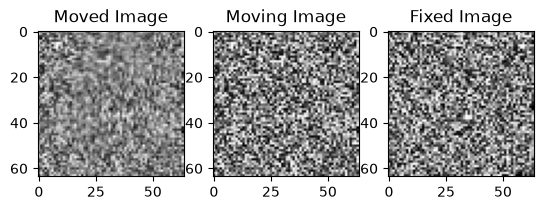

Saved image slices to .\image_slices_trial_0.png


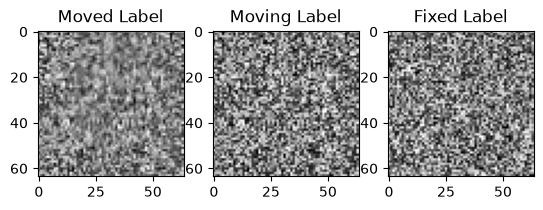

Saved label slices to .\label_slices_trial_0.png


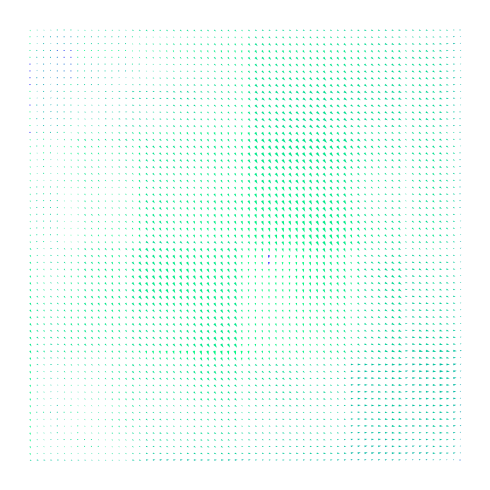

............

12 validation batches scored; mean Dice (untrained net): 0.500


In [24]:
# ==========================================
# 7. VALIDATION - DICE SCORES + QUALITATIVE FIGURES
# ==========================================

def plot_registration_overview(model_save_path, trial,
                               moving_images_val, fixed_images_val, moved_images_val,
                               moving_labels_val, fixed_labels_val, moved_labels_val,
                               ddf_val):
    """Save the qualitative figure pack for the first validation batch of a trial:
    moving/moved/fixed image slices, the same for labels, and the mid-slice flow field."""

    slice_index = 32

    # VISUALLY CHECK FIXED, MOVING, MOVED IMAGES
    plt.subplot(1, 3, 1)
    plt.imshow(tf.squeeze(moved_images_val[0])[slice_index, :, :], cmap='gray')
    plt.title('Moved Image')

    plt.subplot(1, 3, 2)
    plt.imshow(tf.squeeze(moving_images_val[0])[slice_index, :, :], cmap='gray')
    plt.title('Moving Image')

    plt.subplot(1, 3, 3)
    plt.imshow(tf.squeeze(fixed_images_val[0])[slice_index, :, :], cmap='gray')
    plt.title('Fixed Image')

    save_name_img = os.path.join(model_save_path, f"image_slices_trial_{trial}.png")
    plt.savefig(save_name_img, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved image slices to {save_name_img}")

    # VISUALLY CHECK LABELS
    plt.subplot(1, 3, 1)
    plt.imshow(tf.squeeze(moved_labels_val[0])[slice_index, :, :], cmap='gray')
    plt.title('Moved Label')

    plt.subplot(1, 3, 2)
    plt.imshow(tf.squeeze(moving_labels_val[0])[slice_index, :, :], cmap='gray')
    plt.title('Moving Label')

    plt.subplot(1, 3, 3)
    plt.imshow(tf.squeeze(fixed_labels_val[0])[slice_index, :, :], cmap='gray')
    plt.title('Fixed Label')

    save_name_lbl = os.path.join(model_save_path, f"label_slices_trial_{trial}.png")
    plt.savefig(save_name_lbl, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved label slices to {save_name_lbl}")

    # VISUALISE THE PREDICTED DISPLACEMENT FIELD (mid-slice, x/y components only)
    ddf = ddf_val[0].squeeze()           # remove batch/channel dims -> (64, 64, 64, 3)
    mid_plane = ddf[ddf.shape[0] // 2]   # take middle z-slice -> (64, 64, 3)
    flow = mid_plane[::1, ::1]
    ne.plot.flow([flow[..., :2]], width=5)


def evaluate_validation_dice(registration_model, spatial_transformer, test_cache,
                             moving_image_shape, fixed_image_shape,
                             trial=None, model_save_path=None, plot_first_batch=True):
    """Run the deterministic validation generator for all 6 structures, warp the labels with
    the predicted DDFs and collect Dice scores. Optionally render the figure pack for the very
    first batch. Returns the list of per-batch Dice score arrays."""

    dice_scores = []

    for label_num in range(6):
        val_gen = test_generator(test_cache, 4, moving_image_shape, fixed_image_shape,
                                 start_index=None, end_index=None, label_num=label_num,
                                 with_label_inputs=True)

        plotted = False
        while True:
            try:
                (val_inputs, val_outputs) = next(val_gen)
                moving_images_val, fixed_images_val, moving_labels_val, fixed_labels_val = val_inputs
                fixed_images_val, zero_phis_val, fixed_labels_val = val_outputs

                _, ddf_val, _ = registration_model.predict(
                    (moving_images_val, fixed_images_val, moving_labels_val, fixed_labels_val), verbose=0)

                moved_labels_val = spatial_transformer([moving_labels_val, ddf_val])
                moved_images_val = spatial_transformer([moving_images_val, ddf_val])

                if plot_first_batch and label_num == 0 and not plotted:
                    plotted = True
                    plot_registration_overview(model_save_path, trial,
                                               moving_images_val, fixed_images_val, moved_images_val,
                                               moving_labels_val, fixed_labels_val, moved_labels_val,
                                               ddf_val)

                dice_score = np.array(-1.0 * vxm.losses.Dice().loss(
                    tf.convert_to_tensor(moved_labels_val, dtype='float32'),
                    tf.convert_to_tensor(fixed_labels_val, dtype='float32')))
                dice_scores.append(dice_score)

                print('.', end='')
            except (IndexError, StopIteration):
                break

    return dice_scores


# --- Self-check: full validation pass of an UNTRAINED net on the synthetic cache (no dataset needed) ---
# Figures land in the notebook folder; expect near-random Dice since the weights are untrained.

smoke_model, smoke_transformer = build_registration_network(
    get_model(moving_image_shape, fixed_image_shape, with_label_inputs=False),
    moving_image_shape, fixed_image_shape)

smoke_dice = evaluate_validation_dice(smoke_model, smoke_transformer, fake_cache,
                                      moving_image_shape, fixed_image_shape,
                                      trial=0, model_save_path='.', plot_first_batch=True)

print(f"\n\n{len(smoke_dice)} validation batches scored; mean Dice (untrained net): {np.mean(smoke_dice):.3f}")


### 8. Training loop

One trial = 32 optimiser steps + a full 6-structure validation pass. Curves (total loss, similarity head,
regularisation head and validation Dice) are saved as PNGs per trial into
`H1_Experiments/<name>_Part_1_Checkpoints_More_Epochs`. In the Keras history, `transformer_loss` is the
similarity head and `conv3d_*_loss` the regulariser. Interrupted runs resume from saved weights and history
by passing `(last_trial, latest_weights)`.


In [25]:
# ==========================================
# 8. TRAINING LOOP
# ==========================================

def train_model(train_cache, test_cache, similarity_metric, weak_supervision, experiment_name,
                last_trial=None, latest_weights=None, Verbose=False):
    """Fit the registration network trial by trial. One trial = 32 optimiser steps + full validation."""

    model_save_path = f'H1_Experiments/{experiment_name}_Part_1_Checkpoints_More_Epochs'
    if not os.path.exists(model_save_path):
        os.mkdir(model_save_path)

    for lambda_param in [0.1]:  # incase you want to tune the regularization scalar

        # =============================================================================
        # Build the backbone model and wrap it into the registration network
        # =============================================================================

        backbone = get_model(moving_image_shape, fixed_image_shape, with_label_inputs=False)
        registration_model, spatial_transformer = build_registration_network(backbone, moving_image_shape, fixed_image_shape)

        print('\nBackbone model inputs and outputs:')
        print('    input shape: ', ', '.join(str(t.shape) for t in backbone.inputs))
        print('    output shape:', ', '.join(str(t.shape) for t in backbone.outputs))

        print('\nRegistration network inputs and outputs:')
        print('    input shape: ', ', '.join(str(t.shape) for t in registration_model.inputs))
        print('    output shape:', ', '.join(str(t.shape) for t in registration_model.outputs))

        # =============================================================================
        # Compile with the configured loss grid
        # =============================================================================

        loss_functions, loss_weights = configure_losses(similarity_metric, weak_supervision, lambda_param)

        registration_model.compile(optimizer='Adam', loss=loss_functions, loss_weights=loss_weights)

        # =========================================================================
        # Resume from last trial
        # =========================================================================

        if latest_weights is not None:
            print(f"Resuming from {latest_weights} (trial {last_trial})")
            registration_model.load_weights(latest_weights)
            start_trial = last_trial + 1

            # Load arrays
            val_dice = np.load(os.path.join(model_save_path, "val_dice.npy")).tolist()
            transformer_losses = np.load(os.path.join(model_save_path, "transformer_losses.npy")).tolist()
            losses = np.load(os.path.join(model_save_path, "losses.npy")).tolist()
            conv3d_losses = np.load(os.path.join(model_save_path, "conv3d_losses.npy")).tolist()

            # Index from 0 to trial_num
            val_dice = val_dice[:last_trial + 1]
            transformer_losses = transformer_losses[:last_trial + 1]
            losses = losses[:last_trial + 1]
            conv3d_losses = conv3d_losses[:last_trial + 1]

        else:
            print("No previous weights found, starting fresh")
            start_trial = 0
            val_dice = []
            losses = []
            transformer_losses = []
            conv3d_losses = []

        # =============================================================================
        # Trial loop
        # =============================================================================

        batch_size = 8 # Decrease this if you are running out of RAM - set to 4, 8, 16 ect.

        train_gen = train_generator_(train_cache, batch_size, moving_image_shape, fixed_image_shape, with_label_inputs=True)

        num_trials = 1024 # This may be way above what we require

        for trial in range(start_trial, num_trials):
            print(f'\nTrial {trial} / {num_trials-1}:')

            hist = registration_model.fit(train_gen, epochs=1, steps_per_epoch=32, verbose=1);

            dice_scores = evaluate_validation_dice(
                registration_model, spatial_transformer, test_cache,
                moving_image_shape, fixed_image_shape,
                trial=trial, model_save_path=model_save_path, plot_first_batch=True)

            values = [arr.item() for arr in dice_scores]
            print(values)

            losses.append(hist.history["loss"][0])
            transformer_losses.append(hist.history["transformer_loss"][0])          # similarity head
            conv_loss_key = next(
                (key for key in hist.history.keys() 
                 if key.startswith('conv3d_') and key.endswith('_loss')),
                None
            )               
            conv3d_losses.append(hist.history[conv_loss_key][0])                     # regularisation head
            val_dice.append(np.mean(dice_scores))

            # Training curves for this trial
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.subplots_adjust(wspace=0.5) 

            plt.plot(losses, label="Total Loss")
            plt.plot(transformer_losses, label="Similarity Loss")
            plt.xlabel('Trials')
            plt.ylabel('Losses')
            plt.legend()  

            plt.subplot(1, 3, 2)
            plt.plot(conv3d_losses, label="Regularization Loss")
            plt.xlabel('Trials')
            plt.ylabel('Losses')
            plt.legend()  

            plt.subplot(1, 3, 3)
            plt.plot(val_dice, 'r')
            plt.xlabel('Trials')
            plt.ylabel('Dice')

            # Save figure with unique filename
            save_name = os.path.join(model_save_path, f"training_curves_trial_{trial}.png")
            plt.savefig(save_name, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"Saved plot to {save_name}")

            print('    Validation Dice: ', np.mean(dice_scores))


# --- Self-check: verify the trainer's collaborators are wired up correctly (no data needed) ---

import inspect

print("train_model", inspect.signature(train_model))
print()
for fn in [get_model, build_registration_network, configure_losses, train_generator_, test_generator, evaluate_validation_dice]:
    print(f"    {fn.__name__}{inspect.signature(fn)}")


train_model (train_cache, test_cache, similarity_metric, weak_supervision, experiment_name, last_trial=None, latest_weights=None, Verbose=False)

    get_model(moving_image_shape, fixed_image_shape, with_label_inputs=True, up_filters=[64, 128, 256], down_filters=[256, 128, 64, 32])
    build_registration_network(backbone, moving_image_shape, fixed_image_shape)
    configure_losses(similarity_metric, weak_supervision, lambda_param)
    train_generator_(cache, batch_size, moving_image_shape, fixed_image_shape, with_label_inputs=True)
    test_generator(cache, batch_size, moving_image_shape, fixed_image_shape, start_index, end_index, label_num, with_label_inputs=True)
    evaluate_validation_dice(registration_model, spatial_transformer, test_cache, moving_image_shape, fixed_image_shape, trial=None, model_save_path=None, plot_first_batch=True)


### 9. Orchestrator

Same entry point the sweep cells below already call: cache both splits, then hand off to `train_model`.
Nothing downstream changes.


In [26]:
# ==========================================
# 9. ORCHESTRATOR - TIE EVERYTHING TOGETHER
# ==========================================

def run_experiments(name, intensity_metric, weakly_supervised, train_path, val_path ,Verbose=False):
    """Entry point used by the experiment-sweep cells: cache both splits, then train."""
    os.environ['CUDA_VISIBLE_DEVICES']='1'
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

    train_cache = load_dataset_into_cache(train_path, moving_image_shape, fixed_image_shape, with_label_inputs=True)
    test_cache = load_dataset_into_cache(val_path, moving_image_shape, fixed_image_shape, with_label_inputs=True)

    train_model(train_cache, test_cache, intensity_metric, weakly_supervised, experiment_name=name, Verbose=Verbose)


# --- Self-check: the orchestrator contract, no data required ---

print(inspect.signature(run_experiments))
print("\nWaiting on dataset directories:")
print("    <train_path>/{us_images, mr_images, us_labels, mr_labels}")
print("    <val_path>  /{us_images, mr_images, us_labels, mr_labels}")


(name, intensity_metric, weakly_supervised, train_path, val_path, Verbose=False)

Waiting on dataset directories:
    <train_path>/{us_images, mr_images, us_labels, mr_labels}
    <val_path>  /{us_images, mr_images, us_labels, mr_labels}


In [27]:
for weak_supervision in [[True,"unsupervised"]]:
    for intensity_metric in ["NCC"]:
        for data in [["nifti_data_preprocessed/train", "nifti_data_preprocessed/val"], ["nifti_data/train", "nifti_data/val"]]:
        
            if data[0] == "nifti_data/train":
                name = f"{intensity_metric}_{weak_supervision[1]}_no_preprocessing"
            elif data[0] == "nifti_data_preprocessed/train":
                name = f"{intensity_metric}_{weak_supervision[1]}_affine_preprocessing"
                
            run_experiments(name,intensity_metric, weak_supervision[0], data[0], data[1])

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'nifti_data_preprocessed/train\\mr_images'

In [ ]:
for weak_supervision in [[True,"unsupervised"]]:
    for intensity_metric in ["NCC"]:
        for data in [["nifti_data/train", "nifti_data/val"]]:
        
            if data[0] == "nifti_data/train":
                name = f"{intensity_metric}_{weak_supervision[1]}_no_preprocessing"
            elif data[0] == "nifti_data_preprocessed/train":
                name = f"{intensity_metric}_{weak_supervision[1]}_affine_preprocessing"
                
            run_experiments(name,intensity_metric, weak_supervision[0], data[0], data[1])

Error: No connection selected.

In [ ]:
for weak_supervision in [[False,"unsupervised"]]:
    for intensity_metric in ["NCC"]:
        for data in [["nifti_data/train", "nifti_data/val"]]:
        
            if data[0] == "nifti_data/train":
                name = f"{intensity_metric}_{weak_supervision[1]}_no_preprocessing"
            elif data[0] == "nifti_data_preprocessed/train":
                name = f"{intensity_metric}_{weak_supervision[1]}_affine_preprocessing"
                
            run_experiments(name,intensity_metric, weak_supervision[0], data[0], data[1])

Error: No connection selected.

In [ ]:
for weak_supervision in [[False,"unsupervised"]]:
    for intensity_metric in ["NCC"]:
        for data in [["nifti_data/train", "nifti_data/val"], ["nifti_data_preprocessed/train", "nifti_data_preprocessed/val"]]:
        
            if data[0] == "nifti_data/train":
                name = f"{intensity_metric}_{weak_supervision[1]}_no_preprocessing"
            elif data[0] == "nifti_data_preprocessed/train":
                name = f"{intensity_metric}_{weak_supervision[1]}_affine_preprocessing"
                
            run_experiments(name,intensity_metric, weak_supervision[0], data[0], data[1])

Error: No connection selected.